## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
import sklearn.tree as tree
from sklearn.model_selection import GroupKFold
import lime
import lime.lime_tabular
from sklearn.inspection import permutation_importance

## Load model and data

In [3]:
with open('models/decision-tree-trained.pkl', 'rb') as file:
    dt_model = pickle.load(file)

/opt/miniconda3/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.6.1 when using version 1.7.1. This might lead to brea

In [4]:
data = pd.read_csv("data/cleaned_static_features.csv",index_col=0)
with open("data/groups.pkl", 'rb') as file:
    groups = pickle.load(file)
disorders = ["Voice Disorders", "Neurological and Neurodegenerative Disorders", "Mood and Psychiatric Disorders","Respiratory Disorders"]
y_voice = data["Voice Disorders"].copy().to_numpy()
X_df = data.copy().drop(columns=["participant_id", "session_id","task_name","participant_id_int"]+disorders)
feature_names = X_df.columns
X = X_df.to_numpy()

In [5]:
feature_names = data.copy().drop(columns=["participant_id", "session_id","task_name","participant_id_int"]+disorders).columns

In [6]:
category_dict = {
    "spectral": [
        "spectralFlux_sma3_amean", "spectralFlux_sma3_stddevNorm", "spectralFluxV_sma3nz_amean", "spectralFluxV_sma3nz_stddevNorm",
        "spectralFluxUV_sma3nz_amean", "spectral_gravity", "spectral_std_dev", "spectral_skewness", "spectral_kurtosis",
        "alphaRatioV_sma3nz_amean", "alphaRatioV_sma3nz_stddevNorm", "alphaRatioUV_sma3nz_amean",
        "hammarbergIndexV_sma3nz_amean", "hammarbergIndexV_sma3nz_stddevNorm", "hammarbergIndexUV_sma3nz_amean", "hammarbergIndexUV_sma3nz_stddevNorm",
        "slopeV0-500_sma3nz_amean", "slopeV0-500_sma3nz_stddevNorm", "slopeV500-1500_sma3nz_amean", "slopeV500-1500_sma3nz_stddevNorm",
        "slopeUV0-500_sma3nz_amean", "slopeUV500-1500_sma3nz_amean", "spectral_slope", "spectral_tilt"
    ],
    "mfcc": [
        "mfcc1_sma3_amean", "mfcc1_sma3_stddevNorm","mfcc2_sma3_amean", "mfcc2_sma3_stddevNorm", 
        "mfcc3_sma3_amean", "mfcc3_sma3_stddevNorm", "mfcc4_sma3_amean", "mfcc4_sma3_stddevNorm",
        "mfcc1V_sma3nz_amean", "mfcc1V_sma3nz_stddevNorm","mfcc2V_sma3nz_amean", "mfcc2V_sma3nz_stddevNorm", 
        "mfcc3V_sma3nz_amean", "mfcc3V_sma3nz_stddevNorm", "mfcc4V_sma3nz_amean", "mfcc4V_sma3nz_stddevNorm" 
    ],
    "harmonic": [
        "logRelF0-H1-H2_sma3nz_amean", "logRelF0-H1-H2_sma3nz_stddevNorm", 
        "logRelF0-H1-A3_sma3nz_amean", "logRelF0-H1-A3_sma3nz_stddevNorm"
    ],
    "intensity": [
        "loudness_sma3_amean", "loudness_sma3_stddevNorm", "loudness_sma3_percentile20.0",
        "loudness_sma3_percentile50.0", "loudness_sma3_percentile80.0", "loudness_sma3_pctlrange0-2",
        "loudness_sma3_meanRisingSlope", "loudness_sma3_stddevRisingSlope", "loudness_sma3_meanFallingSlope", "loudness_sma3_stddevFallingSlope",
        "mean_intensity_db", "std_intensity_db", "range_ratio_intensity_db", "equivalentSoundLevel_dBp", "loudnessPeaksPerSec",
    ],
    "voice-quality-acoustic": [
        "HNRdBACF_sma3nz_amean", "HNRdBACF_sma3nz_stddevNorm", "mean_hnr_db", "std_hnr_db",
        "stoi", "pesq", "si_sdr"
    ],
    "pitch": [
        "F0semitoneFrom27.5Hz_sma3nz", "F0semitoneFrom27.5Hz_sma3nz_stddevNorm", "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
        "F0semitoneFrom27.5Hz_sma3nz_percentile50.0", "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
        "F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2", "F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope",
        "F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope", "F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope", "F0semitoneFrom27.5Hz_sma3nz_amean",
        "F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope", "mean_f0_hertz", "std_f0_hertz"
    ],
    "formants": [
        "mean_f1_loc", "std_f1_loc", "mean_b1_loc", "std_b1_loc", "mean_f2_loc", "std_f2_loc", "mean_b2_loc", "std_b2_loc",
        "F0semitoneFrom27.5Hz_sma3nz_amean", "F1frequency_sma3nz_amean", "F1frequency_sma3nz_stddevNorm", "F1bandwidth_sma3nz_amean", 
        "F1bandwidth_sma3nz_stddevNorm", "F1amplitudeLogRelF0_sma3nz_amean", "F1amplitudeLogRelF0_sma3nz_stddevNorm",
        "F2frequency_sma3nz_amean", "F2frequency_sma3nz_stddevNorm", "F2bandwidth_sma3nz_amean", "F2bandwidth_sma3nz_stddevNorm",
        "F2amplitudeLogRelF0_sma3nz_amean", "F2amplitudeLogRelF0_sma3nz_stddevNorm", "F3frequency_sma3nz_amean",
        "F3frequency_sma3nz_stddevNorm", "F3bandwidth_sma3nz_amean", "F3bandwidth_sma3nz_stddevNorm", "F3amplitudeLogRelF0_sma3nz_amean",
        "F3amplitudeLogRelF0_sma3nz_stddevNorm"
    ],
    "voice-quality-phonetic": [
        "jitterLocal_sma3nz_amean", "local_jitter", "localabsolute_jitter", "rap_jitter", "ppq5_jitter", "ddp_jitter",
        "shimmerLocaldB_sma3nz", "local_shimmer", "localDB_shimmer", "apq3_shimmer", "apq5_shimmer", "apq11_shimmer", "dda_shimmer",
        "cepstral_peak_prominence_mean", "cepstral_peak_prominence_std",
        "jitterLocal_sma3nz_stddevNorm", "shimmerLocaldB_sma3nz_amean", "shimmerLocaldB_sma3nz_stddevNorm"
    ],
    "temporal-rhythmic": [
        "duration", "speaking_rate", "articulation_rate", "phonation_ratio", "pause_rate", "mean_pause_duration",
        "VoicedSegmentsPerSec", "MeanVoicedSegmentLengthSec", "StddevVoicedSegmentLengthSec",
        "MeanUnvoicedSegmentLength", "StddevUnvoicedSegmentLength"
    ]
}

feature_cat_dict = {}
for feat in feature_names:
    for feat_cat in category_dict:
        if feat in category_dict[feat_cat]:
            feature_cat_dict[feat] = feat_cat

acoustic_feats = [category_dict[feat_cat] for feat_cat in category_dict if feat_cat in ["spectral", "mfcc", "harmonic", "voice-quality-acoustic", "intensity"]]
phonetic_feats = [category_dict[feat_cat] for feat_cat in category_dict if feat_cat not in ["spectral", "mfcc", "harmonic", "voice-quality", "intensity"]]

## Train and test

In [7]:
def train_test_split_groups(y, groups, total_n_groups:int, split_size:float=0.15):
    n_test_groups = int(total_n_groups*0.15)
    group_ones = groups[np.where(y==1)[0]]
    group_zeros = groups[np.where(y==0)[0]]
    test_groups_one = np.random.choice(group_ones, int(n_test_groups/2), replace=False)
    test_groups_zero = np.random.choice(group_zeros, int(n_test_groups/2), replace=False)
    test_groups = np.concatenate((test_groups_one, test_groups_zero))
    train_groups = np.array([g for g in groups if g not in test_groups])
    train_inds = np.array([i for i in range(len(y)) if groups[i] in train_groups])
    test_inds = np.array([i for i in range(len(y)) if groups[i] in test_groups])
    return train_inds, test_inds

In [8]:
train_idx, test_idx = train_test_split_groups(y_voice, groups, total_n_groups=440)
X_train, y_train = X[train_idx], y_voice[train_idx]
X_test, y_test = X[test_idx], y_voice[test_idx]

gkf = GroupKFold(n_splits=7,shuffle=False)
fold_results = []

for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups[train_idx])):
    # Train/test split at group level
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]

    # Fit on training groups
    dt_model.fit(X_tr, y_tr)

    # Evaluate on training groups (report group-level aggregated performance)
    y_tr_pred = dt_model.predict(X_tr)
    train_f1 = f1_score(y_tr, y_tr_pred, average='weighted')

    # Evaluate on held-out group (validation)
    y_val_pred = dt_model.predict(X_val)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    fold_results.append({
        'fold': fold_idx,
        'train_idx_count': len(tr_idx),
        'val_idx_count': len(val_idx),
        'train_f1': train_f1,
        'val_f1': val_f1,
        'val_groups': np.unique(groups[val_idx]).tolist()
    })

# Convert to DataFrame for easier plotting/analysis
decision_tree_gkf_fold_results = pd.DataFrame(fold_results)
print('Per-fold GKF results (first 10 rows):')
decision_tree_gkf_fold_results.head(10)

Per-fold GKF results (first 10 rows):


,fold,train_idx_count,val_idx_count,train_f1,val_f1,val_groups
0,0,13948,2324,0.670246,0.653975,"[0, 1, 4, 5, 7, 8, 9, 14, 15, 21, 31, 38, 39, ..."
1,1,13949,2323,0.675090,0.656391,"[1, 2, 6, 7, 9, 10, 12, 13, 26, 27, 40, 41, 44..."
2,2,13950,2322,0.680334,0.610281,"[15, 16, 17, 18, 21, 22, 27, 28, 29, 30, 31, 3..."
3,3,13939,2333,0.672562,0.641982,"[3, 4, 18, 19, 36, 37, 38, 43, 44, 48, 49, 52,..."
4,4,13948,2324,0.673254,0.663530,"[23, 24, 25, 26, 28, 29, 42, 43, 45, 51, 52, 5..."
5,5,13950,2322,0.670908,0.678316,"[2, 3, 5, 6, 13, 14, 15, 16, 17, 20, 25, 34, 3..."
6,6,13948,2324,0.677629,0.633834,"[10, 11, 12, 19, 30, 31, 35, 36, 45, 46, 53, 5..."


In [9]:
# final eval
y_test_preds = dt_model.predict(X_test)
test_f1 = f1_score(y_test, y_test_preds, average="weighted")
print(f"Test F1 (weighted): {np.round(test_f1,2)}")

Test F1 (weighted): 0.68


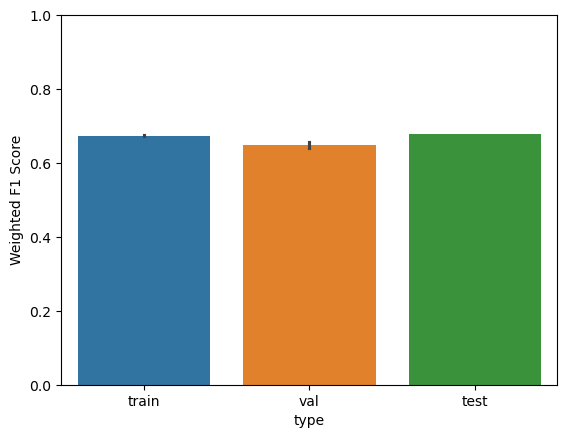

In [10]:
train_f1 = decision_tree_gkf_fold_results["train_f1"].mean()
val_f1 = decision_tree_gkf_fold_results["val_f1"].mean()

results_dict = {"f1":[], "type":[]}
for idx,row in decision_tree_gkf_fold_results.iterrows():
    results_dict["f1"].append(row.train_f1)
    results_dict["type"].append("train")
    results_dict["f1"].append(row.val_f1)
    results_dict["type"].append("val")
results_dict["f1"].append(test_f1)
results_dict["type"].append("test")

results_df = pd.DataFrame.from_dict(results_dict)

plt.figure()
sns.barplot(data=results_df, x="type", y="f1", palette="tab10", hue="type", errorbar="se")
plt.ylabel("Weighted F1 Score")
plt.ylim([0, 1.0])
plt.show()

## Explainability

#### Tree structure

InvalidParameterError: The 'decision_tree' parameter of plot_tree must be an instance of 'sklearn.tree._classes.DecisionTreeClassifier' or an instance of 'sklearn.tree._classes.DecisionTreeRegressor'. Got Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(C=1, max_iter=5000, random_state=42))]) instead.

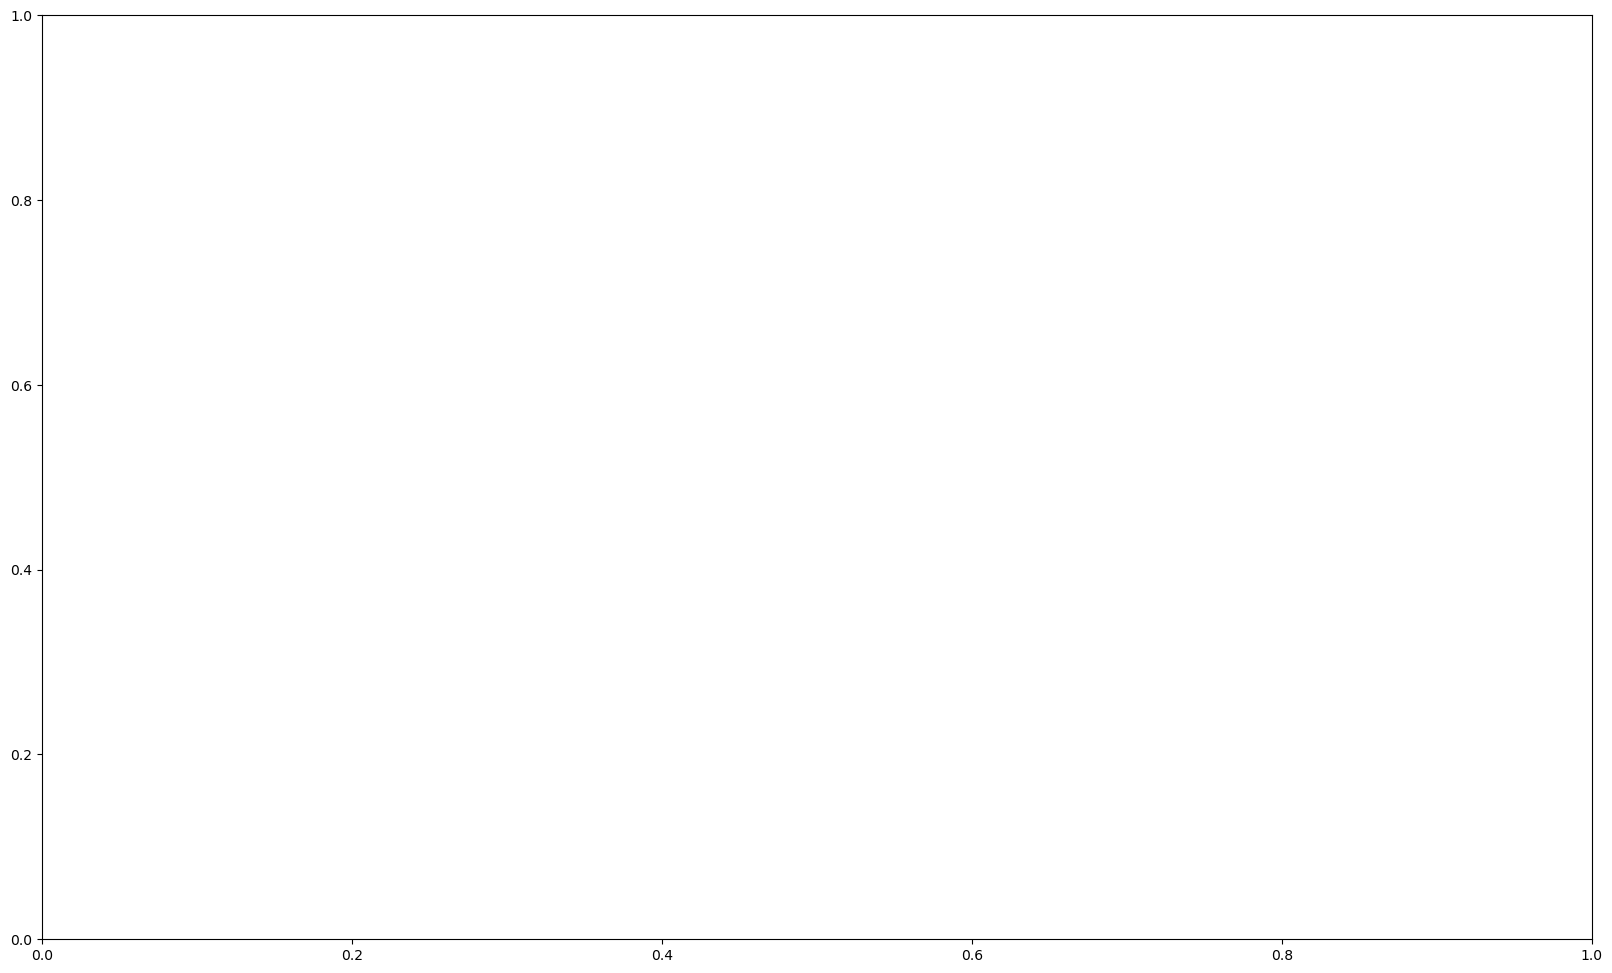

In [11]:
fig,ax = plt.subplots(1,1,figsize=(20,12))
tree.plot_tree(dt_model, proportion=True, max_depth=3, ax=ax,fontsize=12)
plt.tight_layout()
plt.show()

#### Gini impurity
- The impurity-based feature importances. The higher, the more important the feature. The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature.

In [ ]:
mdi_importances = pd.DataFrame.from_dict({
    "mdi":dt_model.feature_importances_, "feature":feature_names
}).sort_values(by="mdi",ascending=False)
mdi_importances

,mdi,feature
78,0.285547,slopeUV0-500_sma3nz_amean
79,0.108979,slopeUV500-1500_sma3nz_amean
40,0.061580,F1frequency_sma3nz_amean
2,0.051314,F0semitoneFrom27.5Hz_sma3nz_percentile20.0
63,0.050325,slopeV0-500_sma3nz_stddevNorm
...,...,...
36,0.000000,logRelF0-H1-H2_sma3nz_amean
35,0.000000,HNRdBACF_sma3nz_stddevNorm
34,0.000000,HNRdBACF_sma3nz_amean
33,0.000000,shimmerLocaldB_sma3nz_stddevNorm


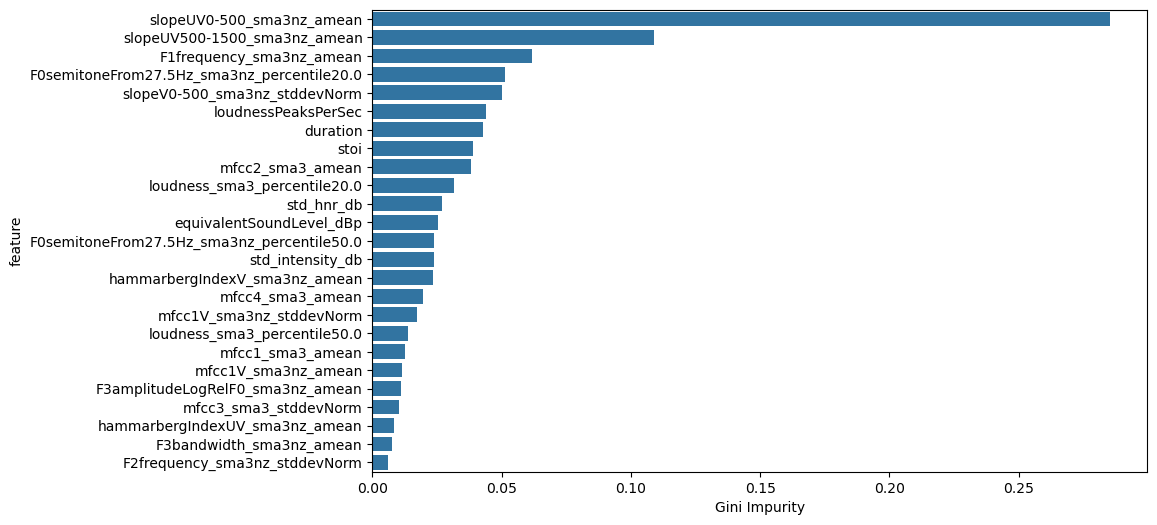

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(10,6))
sns.barplot(data=mdi_importances[:25],x="mdi",y="feature",orient="h")
ax.set_xlabel("Gini Impurity")
plt.show()

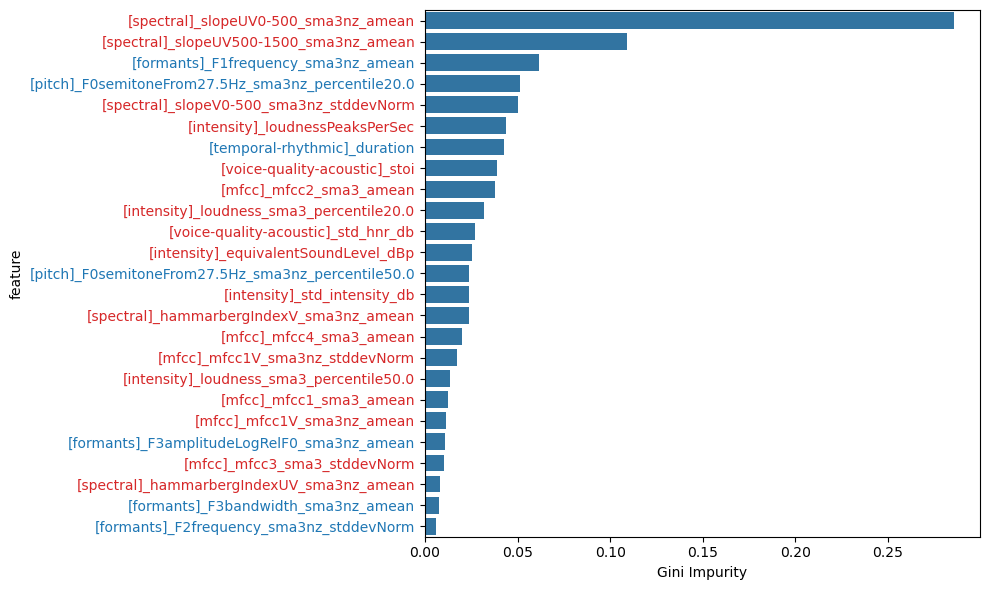

In [ ]:
labels = [f"[{feature_cat_dict.get(lab)}]_"+lab for lab in mdi_importances[:25].feature]
feature_cmap = {
    "spectral":"tab:red",
    "mfcc":"tab:red",
    "harmonic":"tab:red",
    "intensity":"tab:red",
    "voice-quality-acoustic":"tab:red",
    "pitch":"tab:blue",
    "formants":"tab:blue",
    "voice-quality-phonetic":"tab:blue",
    "temporal-rhythmic":"tab:blue"
}
colors =  [feature_cmap.get(feature_cat_dict.get(lab)) for lab in mdi_importances[:25].feature]

fig,ax = plt.subplots(1,1,figsize=(10,6))
sns.barplot(data=mdi_importances[:25],x="mdi",y="feature",orient="h",ax=ax)
ax.set_xlabel("Gini Impurity")
yticklabels = ax.get_yticklabels()
for lab,c in zip(yticklabels,colors):
    lab.set_color(c)
ax.set_yticks(np.arange(len(labels)), labels)
plt.tight_layout()
plt.show()

#### Permutation feature importance
- "Permutation feature importance is a model inspection technique that measures the contribution of each feature to a fitted model’s statistical performance on a given tabular dataset. This technique is particularly useful for non-linear or opaque estimators, and involves randomly shuffling the values of a single feature and observing the resulting degradation of the model’s score [1]. By breaking the relationship between the feature and the target, we determine how much the model relies on such particular feature."

In [12]:
result = permutation_importance(
    dt_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=feature_names[sorted_importances_idx],
)
importances

,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,slopeUV0-500_sma3nz_amean,mfcc3_sma3_amean,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F1amplitudeLogRelF0_sma3nz_stddevNorm,duration,mfcc4_sma3_amean,logRelF0-H1-A3_sma3nz_amean,loudness_sma3_pctlrange0-2,...,F2frequency_sma3nz_amean,equivalentSoundLevel_dBp,F1bandwidth_sma3nz_amean,spectralFlux_sma3_amean,std_intensity_db,mfcc1V_sma3nz_amean,hammarbergIndexV_sma3nz_amean,mean_intensity_db,slopeUV500-1500_sma3nz_amean,alphaRatioUV_sma3nz_amean
0,-0.002697,-0.001011,-0.002360,-0.004383,-0.002023,-0.002360,-0.003709,-0.003709,-0.001686,-0.002360,...,0.046190,0.041470,0.049562,0.060013,0.064396,0.057316,0.068105,0.105866,0.104518,0.173297
1,-0.003709,0.000000,-0.001349,-0.002697,-0.001686,-0.004046,0.001011,-0.003709,-0.000674,0.001349,...,0.041470,0.039784,0.051585,0.062036,0.059002,0.052259,0.073500,0.091369,0.092043,0.166217
2,-0.002360,-0.001349,-0.003034,0.000000,-0.003709,-0.003372,-0.001011,-0.003709,-0.001349,0.000000,...,0.044842,0.041807,0.056979,0.058328,0.060351,0.050910,0.073837,0.101146,0.099123,0.173297
3,-0.004046,-0.005057,-0.000674,-0.001349,-0.000337,-0.000674,-0.001011,-0.001011,0.001011,-0.000337,...,0.046190,0.036076,0.062374,0.057316,0.043493,0.050910,0.087997,0.089009,0.095752,0.179703
4,-0.003709,-0.006743,-0.000674,-0.001349,-0.002023,-0.002360,-0.002360,0.002360,-0.001011,-0.002023,...,0.045179,0.047202,0.049562,0.053608,0.057991,0.060351,0.077208,0.092043,0.106204,0.172623
5,0.000000,-0.003372,-0.002360,-0.005057,-0.001349,-0.002360,-0.002697,0.000000,0.000674,-0.000337,...,0.032367,0.036750,0.044842,0.047876,0.042481,0.052596,0.067431,0.084963,0.104855,0.182063
6,-0.008092,-0.004046,-0.002023,-0.000337,-0.003372,-0.001349,-0.001349,0.000674,-0.002360,-0.000674,...,0.032704,0.035401,0.042481,0.048550,0.052259,0.060351,0.066419,0.097100,0.102158,0.173972
7,-0.008429,0.000337,-0.004720,-0.000337,-0.003034,-0.001011,-0.001349,-0.004383,0.003709,-0.003372,...,0.038436,0.044167,0.050573,0.047876,0.070465,0.056979,0.074174,0.084626,0.100809,0.182401
8,-0.002023,0.000337,-0.003034,-0.004383,-0.001011,-0.002023,0.001349,0.002697,-0.002023,-0.000674,...,0.028995,0.047876,0.040121,0.050573,0.055968,0.066419,0.063048,0.092043,0.100809,0.164194
9,-0.002697,-0.006069,-0.003709,-0.002360,-0.002023,0.000674,-0.001686,0.000337,-0.004046,0.001349,...,0.024949,0.038098,0.037424,0.053608,0.043830,0.070802,0.060688,0.094066,0.107552,0.173297


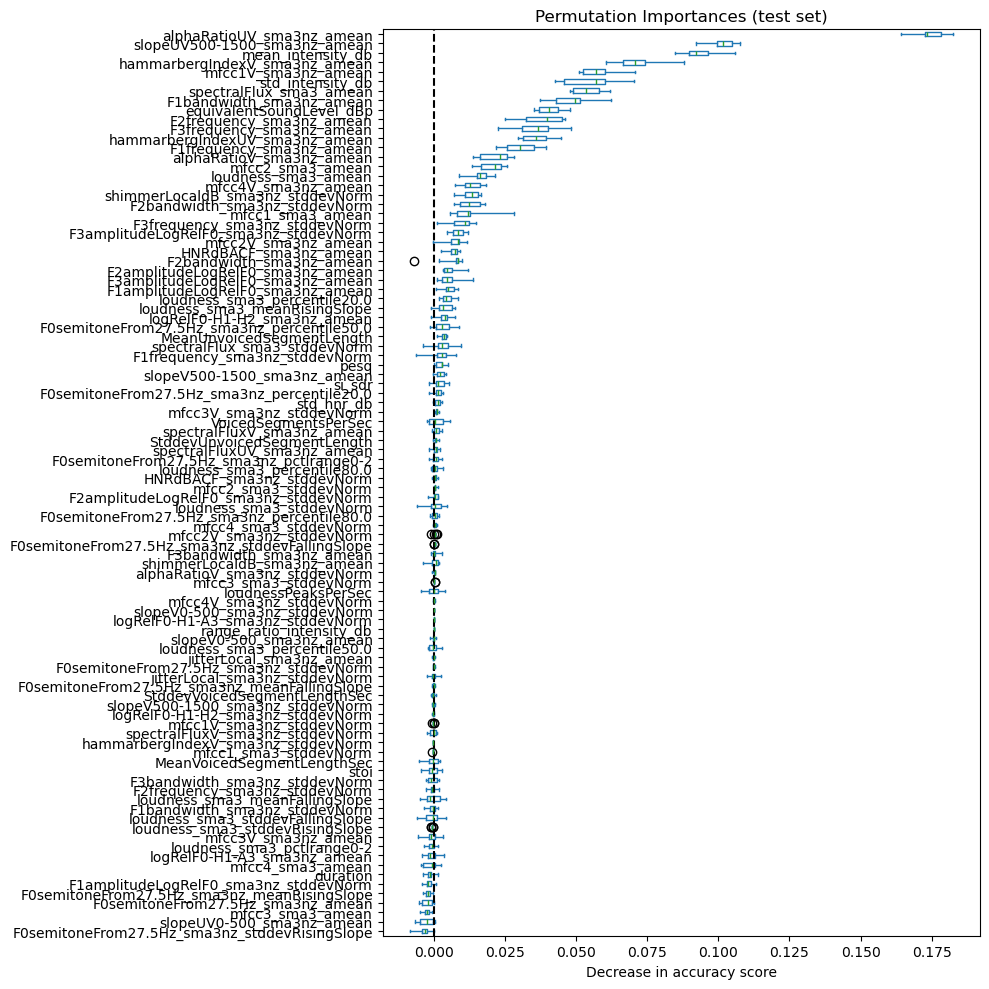

In [13]:
ax = importances.plot.box(vert=False, whis=10, figsize=(10,10))
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
plt.show()

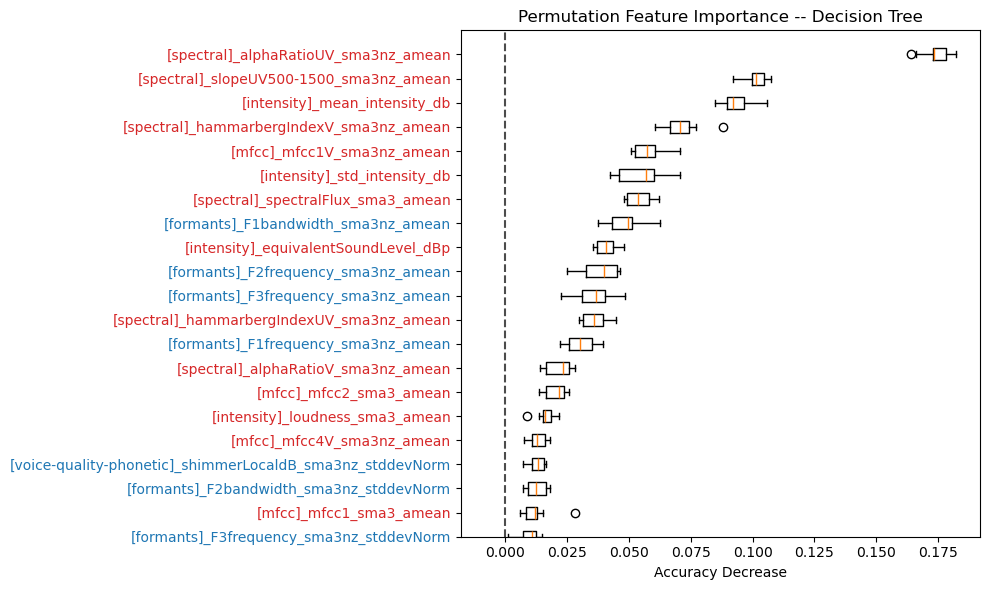

In [21]:
labels = [f"[{feature_cat_dict.get(lab)}]_"+lab for lab in importances.columns]
feature_cmap = {
    "spectral":"tab:red",
    "mfcc":"tab:red",
    "harmonic":"tab:red",
    "intensity":"tab:red",
    "voice-quality-acoustic":"tab:red",
    "pitch":"tab:blue",
    "formants":"tab:blue",
    "voice-quality-phonetic":"tab:blue",
    "temporal-rhythmic":"tab:blue"
}
colors =  [feature_cmap.get(feature_cat_dict.get(lab)) for lab in importances.columns]

fig,ax = plt.subplots(1,1,figsize=(10,6))
ax.boxplot(importances, vert=False)
ax.axvline([0],ls="--",c="k",alpha=0.7)
ax.set_yticks(np.arange(1, len(feature_names)+1), labels)
ax.set_ylim([len(feature_names)-20, len(feature_names)+1])

yticklabels = ax.get_yticklabels()
for lab,c in zip(yticklabels,colors):
    lab.set_color(c)

ax.set_title("Permutation Feature Importance -- Decision Tree")
ax.set_xlabel("Accuracy Decrease")
plt.tight_layout()
plt.show()